In [2]:
!pip install -U classiq
!pip install keyrings.alt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.1/657.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: zstandard
    Found existing installation: zstandard 0.25.0
    Uninstalling zstandard-0.25.0:
      Successfully uninstalled zstandard-0.25.0
  Attempting uninstall: pyomo
    Found existing installation: pyomo 6.10.0
    Uninstalling pyomo-6.10.0:
      Successfully 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import keyring
from keyrings.alt.file import PlaintextKeyring
keyring.set_keyring(PlaintextKeyring())

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from classiq import *

In [6]:
import classiq
classiq.authenticate(overwrite=True)

If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DHTGL-JCKM&scope=offline_access
Your user code: HTGL-JCKM


#OLD_CODE Only works for k= 2^n-1;

In [10]:
# ============================================================
#  PARAMETER LISTS — edit these to sweep different configs
# ============================================================
omegas       = [1]
k_list       = [5]      # Taylor expansion order (int)
b_x_list     = [0]    # b vector x-component  (float)
b_y_list     = [0]    # b vector y-component  (float)
y0_list      = [0,1]    # initial position  y(0) (float)
vy0_list     = [0,1]    # initial velocity y'(0) (float)
t_range_list = [10]     # number of time steps  (int, step size = 0.1)
# ============================================================

import itertools
import os
import pandas as pd


execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)

all_rows = []

for (k, b_x, b_y, y0, vy0, t_range) in itertools.product(
        k_list, b_x_list, b_y_list, y0_list, vy0_list, t_range_list):
    omega=1
    config = f"k={k}, b=[{b_x},{b_y}], y0={y0}, vy0={vy0}, t_range={t_range}"
    print("=" * 65)
    print(f"Config: {config}")
    print("=" * 65)

    # Problem setup

    n       = 2
    M       = np.array([[0, 1], [-1, 0]])
    x_0     = [y0, vy0]
    b       = [b_x, b_y]

    x_0_norm = np.linalg.norm(x_0)
    b_norm   = np.linalg.norm(b)
    M_norm   = np.linalg.norm(M)
    A        = M

    import math
    #T = math.ceil(math.log2(k + 1))
    #T   = int(np.ceil(np.log2(k + 1)))   # ancilla qubits T = int(np.ceil(np.log2(k + 1)))
    #dim = math.ceil(math.log2(n))       # work qubits

    T = k.bit_length()
    dim = n.bit_length()
    # Global state updated by VS1 / VS2 / V
    vs1 = []
    vs2 = []
    v   = []
    c = d = N = 0

    def VS1(t):
        global vs1, c
        c   = 0
        c_m = np.zeros(k + 1)
        m_factorial = 1
        for i in range(k + 1):
            c_m[i]  = (x_0_norm * (pow(t, i))) / m_factorial
            c      += c_m[i]
            m_factorial *= i + 1
        c = np.sqrt(c)
        if t == 0:
            vs1 = np.eye(k + 1, k + 1)
            return
        e = np.zeros(k + 1); e[0] = 1
        w = np.subtract([np.sqrt(c_m[i]) / c for i in range(k + 1)], e)
        vs1 = np.subtract(
            np.identity(k + 1),
            np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
        )

    def VS2(t):
        global vs2, d
        d   = 0
        d_m = np.zeros(k + 1)
        n_factorial = 1
        for i in range(1, k + 1):
            d_m[i - 1]  = (b_norm * (pow(t * M_norm, i - 1))) / n_factorial
            d           += d_m[i - 1]
            n_factorial *= i + 1
        d_m[k] = 0
        d = np.sqrt(d)
        if d == 0:
            vs2 = np.eye(k + 1, k + 1)
            return
        e = np.zeros(k + 1); e[0] = 1
        w = np.subtract([np.sqrt(d_m[i]) / d for i in range(k + 1)], e)
        vs2 = np.subtract(
            np.identity(k + 1),
            np.multiply(2 * (1 / np.inner(w, w)), np.outer(w, w))
        )

    def V():
        global v, N
        v = []
        N = np.sqrt(c * c + d * d)
        if N == 0:
            v = np.eye(2, 2)
        else:
            v.append([c / N, d / N])
            v.append([d / N, -c / N])
            v = np.array(v)


    # Quantum functions
    @qfunc
    def encoding(x: QNum, ancilla: QNum, y: QBit, t: float):
        prob_x_0 = [i / x_0_norm for i in x_0]
        inplace_prepare_amplitudes(prob_x_0, 0.01, x)
        VS1(t); VS2(t); V()
        unitary(v, y)
        control(y == 0, lambda: unitary(vs1, ancilla), lambda: unitary(vs2, ancilla))

    @qfunc
    def evolution(x: QNum, ancilla: QNum):
        u_m = np.array([[1, 0], [0, 1]])
        for i in range(k + 1):
            U = u_m.copy()
            control(ancilla == i, lambda U=U: unitary(U, x))
            u_m = u_m @ A

    @qfunc
    def decoding(ancilla: QNum, y: QBit):
        ws1 = vs1.conj().T
        ws2 = vs2.conj().T
        w   = v.conj().T
        control(y == 0, lambda: unitary(ws1, ancilla), lambda: unitary(ws2, ancilla))
        unitary(w, y)

    def create_main_for_t(t_val: float):
        @qfunc
        def main(x: Output[QNum[dim]], ancilla: Output[QNum[T]], y: Output[QBit]):
            allocate(x); allocate(ancilla); allocate(y)
            encoding(x, ancilla, y, t_val)
            evolution(x, ancilla)
            decoding(ancilla, y)
        return main


    # Run sweep over time steps
    y_out = []
    y_dash_out = []

    for i in range(t_range + 1):
        t_val = i / 10
        print(f"  t = {t_val:.1f}")
        try:
            qmod  = create_model(create_main_for_t(t_val))
            qmod  = set_execution_preferences(qmod, execution_preferences)
            qprog = synthesize(qmod)
            job   = execute(qprog)
            res   = job.result_value()
            for j in res.parsed_state_vector:
                if int(j.bitstring[:-dim], 2) == 0:
                    amp = np.linalg.norm(j.amplitude) * (N * N)
                    if int(j.bitstring, 2) == 0:
                        y_out.append(amp)
                    if int(j.bitstring, 2) == 1:
                        y_dash_out.append(amp)
        except Exception as ex:
            print(f"    Failed: {ex}")
            y_out.append(np.nan)
            y_dash_out.append(np.nan)


    # Expected (analytical) solution for dx/dt = [[0,1],[-1,0]] x + b

    t_values       = [i / 10 for i in range(t_range + 1)] #use .npy array
    y_exp          = [y0 * np.cos(t) + vy0 * np.sin(t)  for t in t_values] # multiply omega
    ydash_exp      = [-y0 * np.sin(t) + vy0 * np.cos(t) for t in t_values] # missing omega

    A0 = vy0/omega
    B0 = y0

    # Expected energies calculated from the formulas
    y_values = [A0 * np.sin(t) + B0 * np.cos(t) for t in t_values]
    ydash_values = [A0 * omega * np.cos(t) - B0 * omega * np.sin(t) for t in t_values]

    KE_exp= [(ydash**2) / 2 for ydash in ydash_exp]
    PE_exp = [(omega**2) * (y**2) / 2 for y in y_values]


    # Actual energies calculated from algorithm outputs:
    KE_act = [(ydash_val**2) / 2 for ydash_val in y_dash_out]
    PE_act = [(omega**2) *(y_val**2) / 2 for y_val in y_out]

    #old values
    #KE_exp = [(v**2) / 2 for v in y_exp]
    #PE_exp = [(v**2) / 2 for v in ydash_exp]
    # KE_act = [(v**2) / 2 for v in y_out]
    # PE_act = [(v**2) / 2 for v in y_dash_out]

    # accuracy per row: 100 - 100*|expected - actual| / (expected + 1e-12)
    def row_acc(exp, act):
        if np.isnan(act):
            return "N/A"
        return f"{100 - 100 * abs(exp - act) / (abs(exp) + 1e-12):.4f}%"




    for i in range(t_range + 1):
      all_rows.append({
        "y0": y0,
        "vy0": vy0,
        "bx": b_x,
        "by": b_y,
        "k": k,
        "t": round(t_values[i], 1),
        "kinetic_expected": round(KE_exp[i], 6),
        "kinetic_actual": round(KE_act[i], 6) if not np.isnan(KE_act[i]) else np.nan,
        "potential_expected": round(PE_exp[i], 6),
        "potential_actual": round(PE_act[i], 6) if not np.isnan(PE_act[i]) else np.nan,
        "kinetic_accuracy": round(100 - 100*abs(KE_exp[i]-KE_act[i])/(abs(KE_exp[i])+1e-12), 4) if not np.isnan(KE_act[i]) else np.nan,
        "potential_accuracy": round(100 - 100*abs(PE_exp[i]-PE_act[i])/(abs(PE_exp[i])+1e-12), 4) if not np.isnan(PE_act[i]) else np.nan
    })
# Save
save_path = "/content/drive/MyDrive/harmonic_oscillator/"
os.makedirs(save_path, exist_ok=True)

df = pd.DataFrame(all_rows)
df.to_csv(os.path.join(save_path, "sweep_results_k_y_vy.csv"), index=False)
print(f"Saved all configurations to {save_path}sweep_results_all_configs.csv")


Config: k=5, b=[0,0], y0=0, vy0=0, t_range=10
  t = 0.0
    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new
  t = 0.1
    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new
  t = 0.2
    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket a

/tmp/ipython-input-440/2733081365.py:116: RuntimeWarning: invalid value encountered in scalar divide
  prob_x_0 = [i / x_0_norm for i in x_0]


    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new
  t = 0.7
    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/tickets/new
  t = 0.8
    Failed: 
	'nan' is not a number
		at file 2733081365.py line 117 character 8 in function inplace_prepare_amplitudes
If you need further assistance, please reach out on our Community Slack channel at: https://short.classiq.io/join-slack or open a support ticket at: https://classiq-community.freshdesk.com/support/ticke

#Handles any k

In [21]:
#PARAMETER LISTS


omegas       = [1]
k_list       = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]   # arbitrary k
b_x_list     = [0]
b_y_list     = [0]
y0_list      = [1]
vy0_list     = [1]
t_range_list = [10]



import itertools
import os
import math
import json
import numpy as np
import pandas as pd
from datetime import datetime

from classiq import *


# Execution Preferences


execution_preferences = ExecutionPreferences(
    num_shots=1,
    backend_preferences=ClassiqBackendPreferences(
        backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
    ),
)


# Helper: Pad unitary to power-of-two dimension


def pad_to_power_of_two(U, target_dim):
    padded = np.eye(target_dim, dtype=complex)
    dim = U.shape[0]
    padded[:dim, :dim] = U
    return padded


# Data storage


all_rows = []


# Sweep


for (k, b_x, b_y, y0, vy0, t_range) in itertools.product(
        k_list, b_x_list, b_y_list, y0_list, vy0_list, t_range_list):

    print("=" * 65)
    print(f"Config: k={k}, b=[{b_x},{b_y}], y0={y0}, vy0={vy0}")
    print("=" * 65)

    omega = 1
    n = 2
    M = np.array([[0, 1], [-1, 0]], dtype=float)
    x_0 = np.array([y0, vy0], dtype=float)
    b = np.array([b_x, b_y], dtype=float)

    x_0_norm = np.linalg.norm(x_0)
    b_norm   = np.linalg.norm(b)
    M_norm   = np.linalg.norm(M)

    A = M

    # Proper ancilla sizing
    T = k.bit_length()              # number of qubit
    ancilla_dim =2**T
    dim = int(np.log2(n))           # 1 qubit system register

    #print(f"k+1={k+1}, T={T}, ancilla_dim={ancilla_dim}")


    # Classical LCU coefficient preparation


    def compute_VS1(t):
      c_m = np.zeros(k + 1)
      m_fact = 1
      for i in range(k + 1):
        c_m[i] = (x_0_norm * (t ** i)) / m_fact
        m_fact *= (i + 1)
      c = np.sqrt(np.sum(c_m))
      if c == 0:
        return np.eye(k + 1), 0
      e = np.zeros(k + 1)
      e[0] = 1
      w = np.sqrt(c_m) / c - e
      w_norm_sq = np.inner(w, w)
      if w_norm_sq < 1e-12:          # already aligned with |0⟩ — no reflection needed
          return np.eye(k + 1), c
      vs1 = np.eye(k + 1) - 2 * np.outer(w, w) / w_norm_sq
      return vs1, c

      def compute_VS2(t):
        d_m = np.zeros(k + 1)
        n_fact = 1
      for i in range(1, k + 1):
        d_m[i - 1] = (b_norm * ((t * M_norm) ** (i - 1))) / n_fact
        n_fact *= (i + 1)
      d = np.sqrt(np.sum(d_m))
      if d == 0:
            return np.eye(k + 1), 0
      e = np.zeros(k + 1)
      e[0] = 1
      w = np.sqrt(d_m) / d - e
      w_norm_sq = np.inner(w, w)
      if w_norm_sq < 1e-12:          # already aligned with |0⟩ — no reflection needed
          return np.eye(k + 1), d
      vs2 = np.eye(k + 1) - 2 * np.outer(w, w) / w_norm_sq
      return vs2, d


    # Time evolution


    y_out = []
    y_dash_out = []

    for step in range(t_range + 1):

        t_val = step / 10
        print(f"  t = {t_val:.1f}")

        vs1, c = compute_VS1(t_val)
        vs2, d = compute_VS2(t_val)

        # Pad to ancilla dimension
        vs1_padded = pad_to_power_of_two(vs1, ancilla_dim)
        vs2_padded = pad_to_power_of_two(vs2, ancilla_dim)

        N = math.sqrt(c * c + d * d)
        if N == 0:
            v = np.eye(2)
        else:
            v = np.array([[c/N, d/N],
                          [d/N, -c/N]])

        # ====================================================
        # Quantum circuit
        # ====================================================

        @qfunc
        def main(x: Output[QArray[QBit, dim]],
                 ancilla: Output[QNum[T]],
                 y: Output[QBit]):

            allocate(x)
            allocate(ancilla)
            allocate(y)

            # Safe amplitude prep
            if x_0_norm == 0:
                prob_x_0 = [1.0, 0.0]
            else:
                prob_x_0 = [i / x_0_norm for i in x_0]

            inplace_prepare_amplitudes(prob_x_0, 0.01, x)

            unitary(v, y)

            control(y == 0,
                    lambda: unitary(vs1_padded, ancilla),
                    lambda: unitary(vs2_padded, ancilla))

            # Evolution
            u_m = np.eye(2)
            for i in range(k + 1):
                U = u_m.copy()
                control(ancilla == i,
                        lambda U=U: unitary(U, x))
                u_m = u_m @ A

            # Decode
            control(y == 0,
                    lambda: unitary(vs1_padded.conj().T, ancilla),
                    lambda: unitary(vs2_padded.conj().T, ancilla))

            unitary(v.conj().T, y)


        # Execute


        try:
            qmod  = create_model(main)
            qmod  = set_execution_preferences(qmod, execution_preferences)
            qprog = synthesize(qmod)
            job   = execute(qprog)
            res   = job.result_value()

            y_val = 0
            y_dash_val = 0

            for j in res.parsed_state_vector:
                if int(j.bitstring[:-dim], 2) == 0:
                    amp = abs(j.amplitude) * (N * N)
                    if int(j.bitstring, 2) == 0:
                        y_val = amp
                    if int(j.bitstring, 2) == 1:
                        y_dash_val = amp

            y_out.append(y_val)
            y_dash_out.append(y_dash_val)

        except Exception as ex:
            print(f"    Failed: {ex}")
            y_out.append(np.nan)
            y_dash_out.append(np.nan)


    # Save results


    t_values = [i / 10 for i in range(t_range + 1)]

    # Expected trajectories
    y_exp     = [y0 * np.cos(t) + vy0 * np.sin(t)  for t in t_values]   # multiply omega
    ydash_exp = [-y0 * np.sin(t) + vy0 * np.cos(t) for t in t_values]   # missing omega

    # Corrected expected trajectories using A0/B0 form
    A0 = vy0 / omega
    B0 = y0
    y_values     = [A0 * np.sin(t) + B0 * np.cos(t)           for t in t_values]
    ydash_values = [A0 * omega * np.cos(t) - B0 * omega * np.sin(t) for t in t_values]

    # Expected energies (from corrected formulas)
    KE_exp = [(ydash ** 2) / 2                  for ydash in ydash_values]
    PE_exp = [(omega ** 2) * (y ** 2) / 2       for y     in y_values]

    # Actual energies (from algorithm outputs)
    KE_act = [(ydash_val ** 2) / 2              for ydash_val in y_dash_out]
    PE_act = [(omega ** 2) * (y_val ** 2) / 2   for y_val     in y_out]

    for i in range(t_range + 1):
        all_rows.append({
            "y0":                  y0,
            "vy0":                 vy0,
            "bx":                  b_x,
            "by":                  b_y,
            "k":                   k,
            "t":                   round(t_values[i], 1),
            "kinetic_expected":    round(KE_exp[i], 6),
            "kinetic_actual":      round(KE_act[i], 6) if not np.isnan(KE_act[i]) else np.nan,
            "potential_expected":  round(PE_exp[i], 6),
            "potential_actual":    round(PE_act[i], 6) if not np.isnan(PE_act[i]) else np.nan,
            "kinetic_accuracy":    round(100 - 100 * abs(KE_exp[i] - KE_act[i]) / (abs(KE_exp[i]) + 1e-12), 4)
                                   if not np.isnan(KE_act[i]) else np.nan,
            "potential_accuracy":  round(100 - 100 * abs(PE_exp[i] - PE_act[i]) / (abs(PE_exp[i]) + 1e-12), 4)
                                   if not np.isnan(PE_act[i]) else np.nan,
        })


# Save with Timestamp


base_path = "/content/drive/MyDrive/harmonic_oscillator/"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_folder = os.path.join(base_path, f"run_{timestamp}")
os.makedirs(run_folder, exist_ok=True)

df = pd.DataFrame(all_rows)
csv_path = os.path.join(run_folder, "sweep_results.csv")
df.to_csv(csv_path, index=False)

# Save parameters for reproducibility
params = {
    "k_list":      k_list,
    "y0_list":     y0_list,
    "vy0_list":    vy0_list,
    "t_range_list": t_range_list
}

with open(os.path.join(run_folder, "parameters.json"), "w") as f:
    json.dump(params, f, indent=4)

print(f"\nSaved results to: {csv_path}")

Config: k=1, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=2, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=3, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=4, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=5, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=6, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  t = 1.0
Config: k=7, b=[0,0], y0=1, vy0=1
  t = 0.0
  t = 0.1
  t = 0.2
  t = 0.3
  t = 0.4
  t = 0.5
  t = 0.6
  t = 0.7
  t = 0.8
  t = 0.9
  

#Analysis for changing k

In [22]:
import pandas as pd

# Update path to your CSV
csv_path = "/content/drive/MyDrive/harmonic_oscillator/run_20260228_194305/sweep_results.csv"
df = pd.read_csv(csv_path)

df.head()

,y0,vy0,bx,by,k,t,kinetic_expected,kinetic_actual,potential_expected,potential_actual,kinetic_accuracy,potential_accuracy
0,1,1,0,0,1,0.0,0.500000,0.500,0.500000,0.500,100.0000,100.0000
1,1,1,0,0,1,0.1,0.400665,0.405,0.599335,0.605,98.9181,99.0547
2,1,1,0,0,1,0.2,0.305291,0.320,0.694709,0.720,95.1819,96.3595
3,1,1,0,0,1,0.3,0.217679,0.245,0.782321,0.845,87.4488,91.9881
4,1,1,0,0,1,0.4,0.141322,0.180,0.858678,0.980,72.6313,85.8711


In [32]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

csv_path = "/content/drive/MyDrive/harmonic_oscillator/run_20260228_194305/sweep_results.csv"
df = pd.read_csv(csv_path)

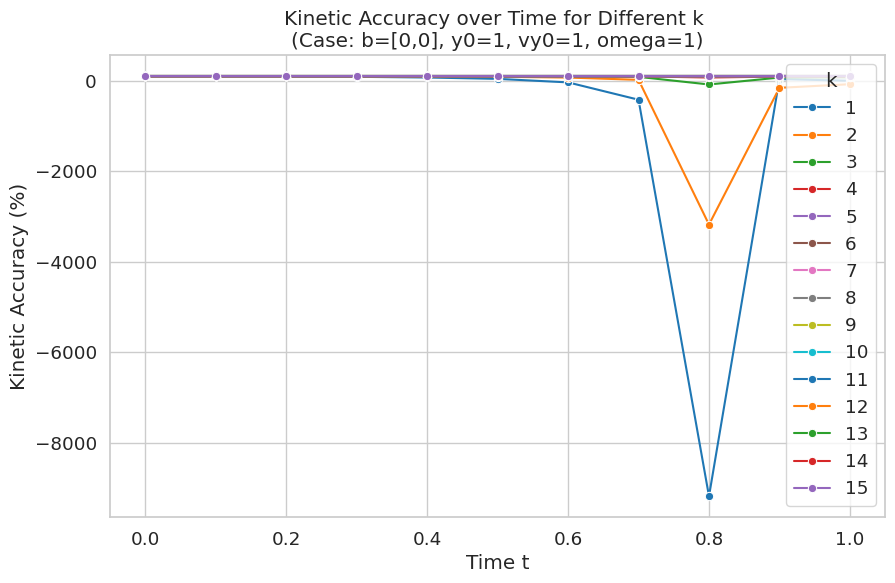

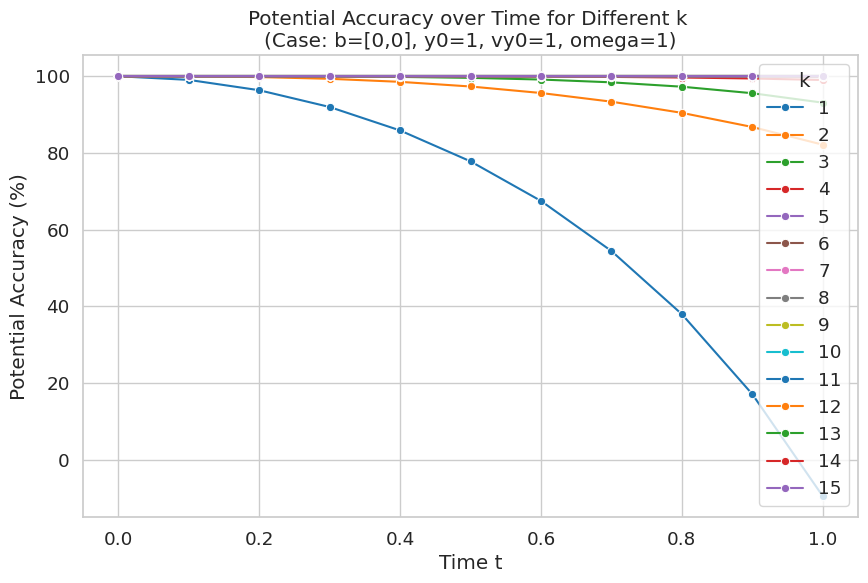

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="t", y="kinetic_accuracy", hue="k", marker="o", palette="tab10")
plt.title("Kinetic Accuracy over Time for Different k \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("Time t")
plt.ylabel("Kinetic Accuracy (%)")
plt.legend(title="k")
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="t", y="potential_accuracy", hue="k", marker="o", palette="tab10")
plt.title("Potential Accuracy over Time for Different k \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("Time t")
plt.ylabel("Potential Accuracy (%)")
plt.legend(title="k")
plt.show()

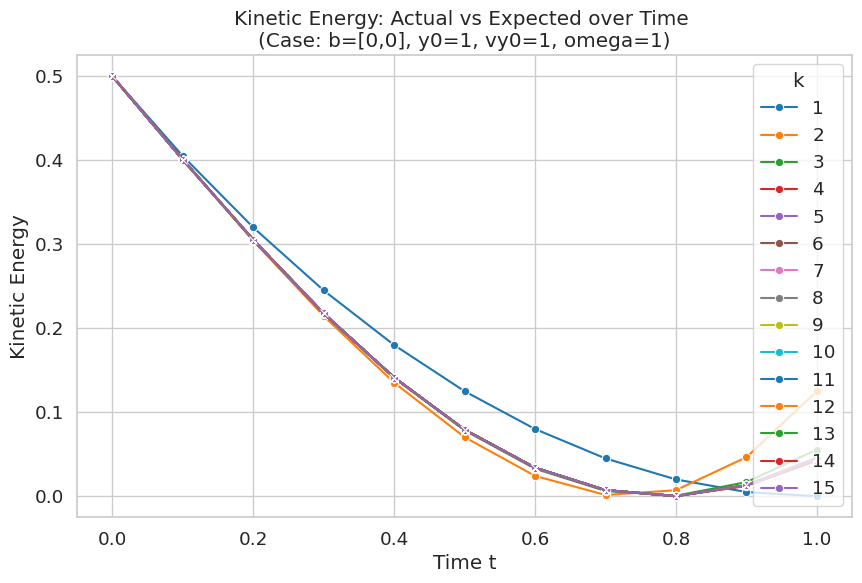

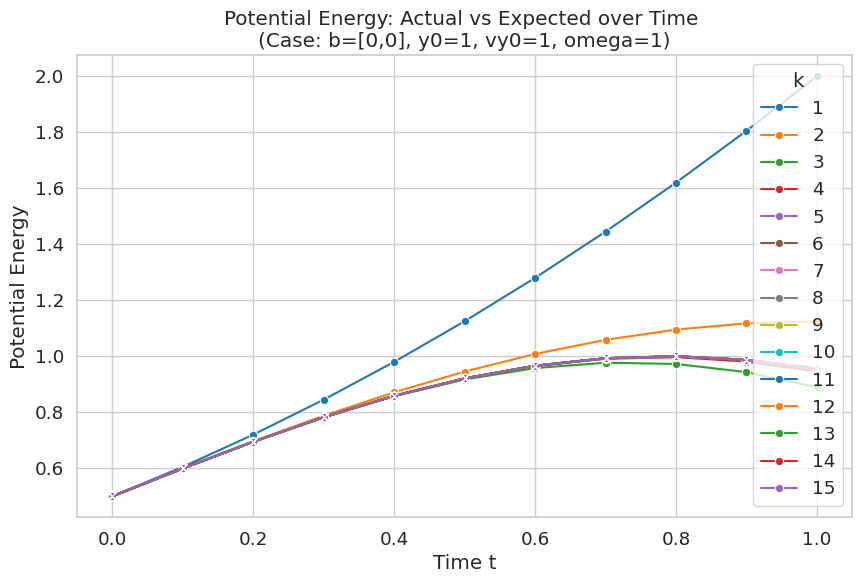

In [44]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="t", y="kinetic_actual", hue="k", marker="o", palette="tab10")
sns.lineplot(data=df, x="t", y="kinetic_expected", hue="k", marker="x", palette="tab10", linestyle="--", legend=False)
plt.title("Kinetic Energy: Actual vs Expected over Time \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("Time t")
plt.ylabel("Kinetic Energy")
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="t", y="potential_actual", hue="k", marker="o", palette="tab10")
sns.lineplot(data=df, x="t", y="potential_expected", hue="k", marker="x", palette="tab10", linestyle="--", legend=False)
plt.title("Potential Energy: Actual vs Expected over Time \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("Time t")
plt.ylabel("Potential Energy")
plt.show()

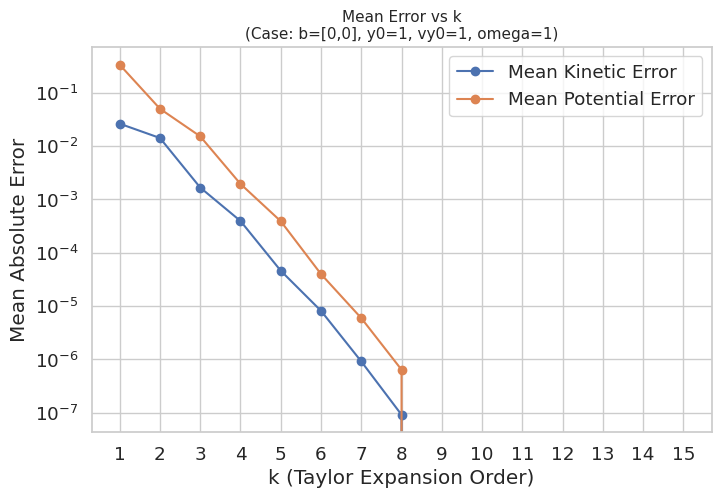

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df["kinetic_error"] = abs(df["kinetic_expected"] - df["kinetic_actual"])
df["potential_error"] = abs(df["potential_expected"] - df["potential_actual"])

# Aggregate over time for each k
error_summary = df.groupby("k")[["kinetic_error", "potential_error"]].mean().reset_index()

# Plot mean errors
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8,5))

plt.plot(error_summary["k"], error_summary["kinetic_error"], marker='o', label="Mean Kinetic Error")
plt.plot(error_summary["k"], error_summary["potential_error"], marker='o', label="Mean Potential Error")

plt.title("Mean Error vs k\n(Case: b=[0,0], y0=1, vy0=1, omega=1)", fontsize=11)
plt.xlabel("k (Taylor Expansion Order)")
plt.ylabel("Mean Absolute Error")
plt.yscale("log")  # optional: log scale for better visualization
plt.xticks(error_summary["k"])
plt.legend()
plt.show()

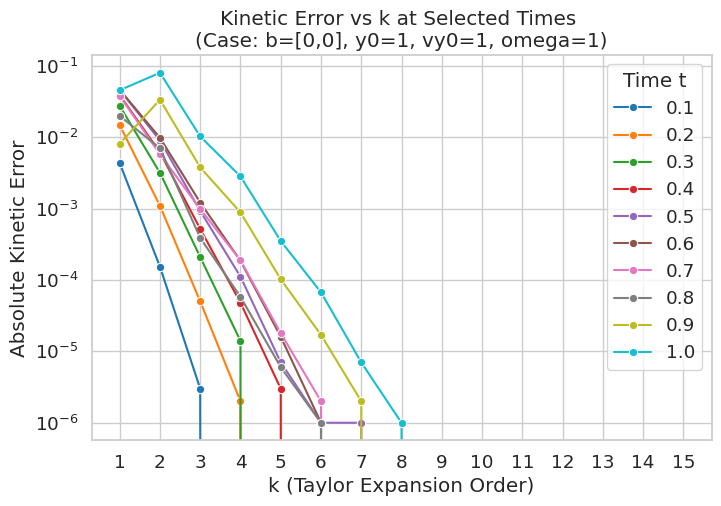

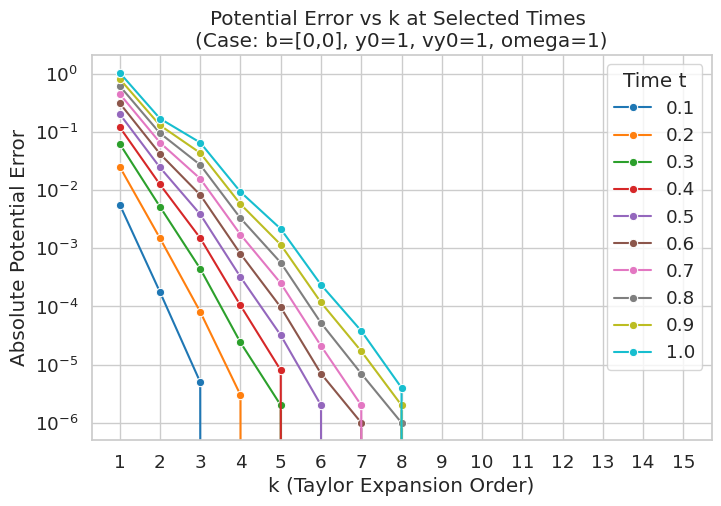

In [47]:
# Compute absolute errors
df["kinetic_error"] = abs(df["kinetic_expected"] - df["kinetic_actual"])
df["potential_error"] = abs(df["potential_expected"] - df["potential_actual"])

# Select times to analyze
selected_times = [0.1,0.2,0.3,0.4,0.5,0.6, 0.7,0.8,0.9,1.0]

# Filter for selected times
df_sel = df[df["t"].isin(selected_times)]

sns.set(style="whitegrid", font_scale=1.2)

# Plot Kinetic Error vs k
plt.figure(figsize=(8,5))
sns.lineplot(data=df_sel, x="k", y="kinetic_error", hue="t", marker="o", palette="tab10")
plt.title("Kinetic Error vs k at Selected Times \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("k (Taylor Expansion Order)")
plt.ylabel("Absolute Kinetic Error")
plt.yscale("log")  # optional: log scale helps visualize plateau
plt.xticks(sorted(df["k"].unique()))
plt.legend(title="Time t")
plt.show()

# Plot Potential Error vs k
plt.figure(figsize=(8,5))
sns.lineplot(data=df_sel, x="k", y="potential_error", hue="t", marker="o", palette="tab10")
plt.title("Potential Error vs k at Selected Times \n(Case: b=[0,0], y0=1, vy0=1, omega=1)")
plt.xlabel("k (Taylor Expansion Order)")
plt.ylabel("Absolute Potential Error")
plt.yscale("log")
plt.xticks(sorted(df["k"].unique()))
plt.legend(title="Time t")
plt.show()